## Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # to see all columns

## Load data

In [2]:
df = pd.read_csv('ipl_2026_deliveries(in).csv')
df.head()

NameError: name 'pd' is not defined

In [7]:
df.shape  # rows and cols

(3517, 21)

In [8]:
df.columns

Index(['match_id', 'season', 'phase', 'match_no', 'date', 'venue',
       'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler',
       'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs',
       'wicket_type', 'player_dismissed', 'fielder'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3517 entries, 0 to 3516
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          3517 non-null   int64  
 1   season            3517 non-null   int64  
 2   phase             3517 non-null   str    
 3   match_no          3517 non-null   int64  
 4   date              3517 non-null   str    
 5   venue             3517 non-null   str    
 6   batting_team      3517 non-null   str    
 7   bowling_team      3517 non-null   str    
 8   innings           3517 non-null   int64  
 9   over              3517 non-null   float64
 10  striker           3517 non-null   str    
 11  bowler            3517 non-null   str    
 12  runs_of_bat       3517 non-null   int64  
 13  extras            3517 non-null   int64  
 14  wide              3517 non-null   int64  
 15  legbyes           3517 non-null   int64  
 16  byes              3517 non-null   int64  
 17  noball

In [39]:
df.isnull().sum()
# gives the missing values count

match_id               0
season                 0
phase                  0
match_no               0
date                   0
venue                  0
batting_team           0
bowling_team           0
innings                0
over                   0
striker                0
bowler                 0
runs_of_bat            0
extras                 0
wide                   0
legbyes                0
byes                   0
noballs                0
wicket_type         3325
player_dismissed    3329
fielder             3365
total_runs             0
is_six                 0
is_four                0
is_wicket              0
phase_group            0
over_number            0
dtype: int64

## how many matches are played ?

In [45]:
df['match_id'].nunique()

16

## What and how many teams are playing ?

In [46]:
df['batting_team'].unique()

<StringArray>
['SRH', 'RCB', 'KKR', 'MI', 'CSK', 'RR', 'GT', 'PBKS', 'LSG', 'DC']
Length: 10, dtype: str

In [13]:
df['batting_team'].nunique()

10

## feature Engineering - Creating new columns

In [14]:
df['total_runs'] = df['runs_of_bat'] + df['extras']  # total run on each ball

df['is_six'] = 0
df['is_four'] = 0
df['is_wicket'] = 0

df.loc[ df['runs_of_bat']==6 , 'is_six'  ] = 1 # runsof bat is 6 , is_six=1
df.loc[ df['runs_of_bat']==4 , 'is_four'  ] = 1
df.loc[ df['wicket_type'].notnull() , 'is_wicket' ]=1

df.head()

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder,total_runs,is_six,is_four,is_wicket
0,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0
1,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0
2,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0
3,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN,6,1,0,0
4,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0


In [47]:
df['over'] = df['over'] + 1

# here we have to create the phase of the game like powerplay , middle overs , death overs
def get_phase(over):
    if over<=6:
        return 'Powerplay(1-6)'
    elif over<=15:
        return 'Middle(7-15)'
    else:
        return 'Death(16-20)'

df['phase_group'] = df['over'].apply(get_phase)
df

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder,total_runs,is_six,is_four,is_wicket,phase_group,over_number
0,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,2.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,Powerplay(1-6),1
1,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,2.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Powerplay(1-6),1
2,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,2.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,Powerplay(1-6),1
3,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,2.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN,6,1,0,0,Powerplay(1-6),1
4,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,2.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,Powerplay(1-6),1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3512,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,19.2,Ravindra Jadeja,Romario Shepherd,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Death(16-20),18
3513,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,19.3,Dhruv Jurel,Romario Shepherd,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Death(16-20),18
3514,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,19.4,Ravindra Jadeja,Romario Shepherd,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Death(16-20),18
3515,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,19.5,Dhruv Jurel,Romario Shepherd,6,0,0,0,0,0,NaN,NaN,NaN,6,1,0,0,Death(16-20),18


## Batting  Analysis

### Which Team scored the most runs ?

In [48]:
edf = df.groupby('batting_team').agg(
    total = ('total_runs','sum')
).reset_index()

edf = edf.sort_values('total',ascending=False)
edf


,batting_team,total
8,RR,690
7,RCB,654
3,KKR,586
9,SRH,585
2,GT,576
0,CSK,544
1,DC,516
5,MI,509
4,LSG,483
6,PBKS,374


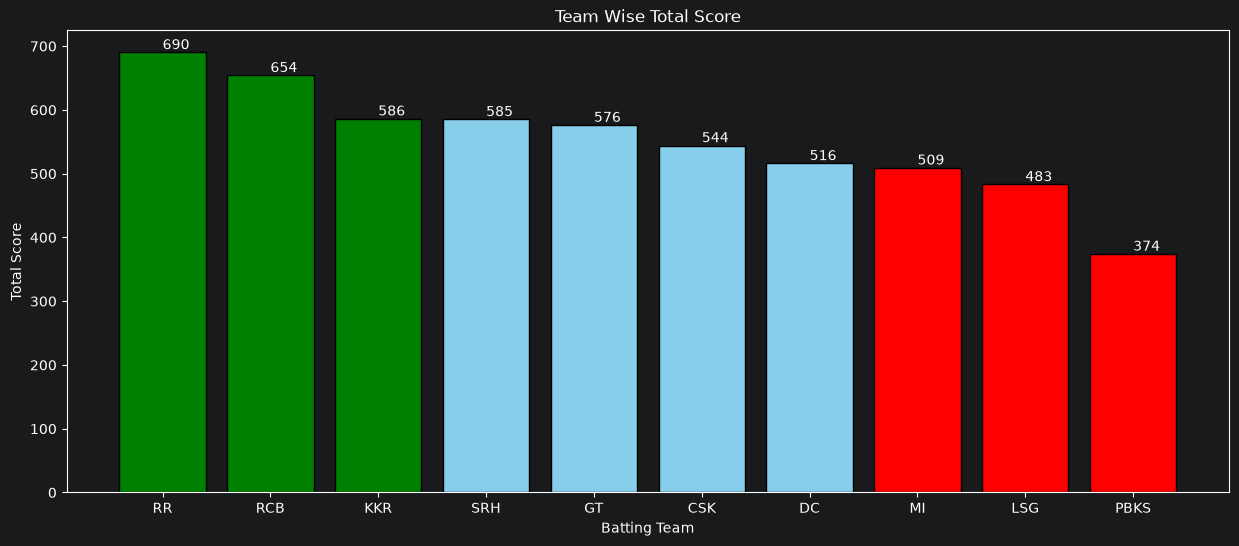

In [49]:
## here we draw the bar graph of most runs scored team wise means total run team wise
plt.figure(figsize=(15,6))
plt.bar(edf['batting_team'],edf['total'],color=['green','green','green','skyblue','skyblue','skyblue','skyblue','red','red','red'],edgecolor='black')
plt.title('Team Wise Total Score')
plt.xlabel('Batting Team')
plt.ylabel('Total Score')

for x,y in zip(edf['batting_team'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

## Team with most sixes and fours

In [52]:
## here we calculate the total no of six, fours and totals runs comming from boundries by each team
edf = df.groupby('batting_team').agg(
    nos = ('is_six','sum'),
    nof = ('is_four','sum')
).reset_index()

edf['score by boundaries'] = edf['nos'] + edf['nof']
edf

,batting_team,nos,nof,score by boundaries
0,CSK,23,50,73
1,DC,22,50,72
2,GT,23,55,78
3,KKR,24,57,81
4,LSG,19,44,63
5,MI,23,50,73
6,PBKS,23,29,52
7,RCB,39,51,90
8,RR,42,59,101
9,SRH,29,50,79


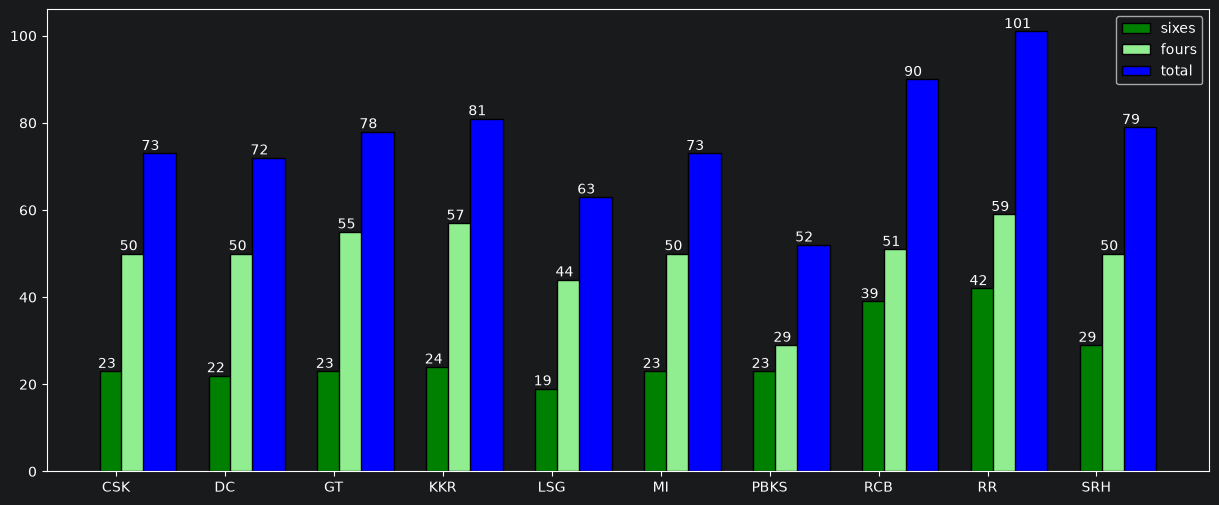

In [54]:
## here we draw the bar graph of no of fours , no of six , total runs from boundries
plt.figure(figsize=(15,6))

xval = np.arange(1,11)  #[1,2,3,4,5,6,7,8,9,10]

plt.bar(xval,edf['nos'],width=0.3,color='green',label='sixes',edgecolor='black')  #[1 2 3 4 5 6 7 8 9 10]
plt.bar(xval+0.2,edf['nof'],width=0.3,color='lightgreen',label='fours',edgecolor='black') #[1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2,10.2]
plt.bar(xval+0.4,edf['score by boundaries'],width=0.3,color='blue',label='total',edgecolor='black')
plt.legend()


for x,y in zip(xval,edf['nos']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.2,edf['nof']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.4,edf['score by boundaries']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')


plt.xticks(xval,edf['batting_team'])

plt.show()

## How many runs did each team score in Powerplay, Middle & Death overs?

In [19]:
## here we show the phase wise total runs from each team . phase like powerplay, midddle overs, death overs
edf = df.groupby(['batting_team','phase_group']).agg(
    total = ('total_runs','sum')
).reset_index()

edf = edf.sort_values(['batting_team','total'],ascending=False)
edf

,batting_team,phase_group,total
28,SRH,Middle(7-15),264
27,SRH,Death(16-20),201
29,SRH,Powerplay(1-6),120
25,RR,Middle(7-15),324
26,RR,Powerplay(1-6),265
24,RR,Death(16-20),101
22,RCB,Middle(7-15),278
21,RCB,Death(16-20),208
23,RCB,Powerplay(1-6),168
19,PBKS,Middle(7-15),153


In [55]:
## here we show the runs of each team phase wise in column
edf = df.pivot_table(index='batting_team',columns='phase_group',values='total_runs',aggfunc='sum').reset_index()
edf

phase_group,batting_team,Death(16-20),Middle(7-15),Powerplay(1-6)
0,CSK,198,236,110
1,DC,186,249,81
2,GT,190,269,117
3,KKR,169,248,169
4,LSG,169,215,99
5,MI,131,268,110
6,PBKS,119,164,91
7,RCB,234,281,139
8,RR,124,364,202
9,SRH,235,263,87


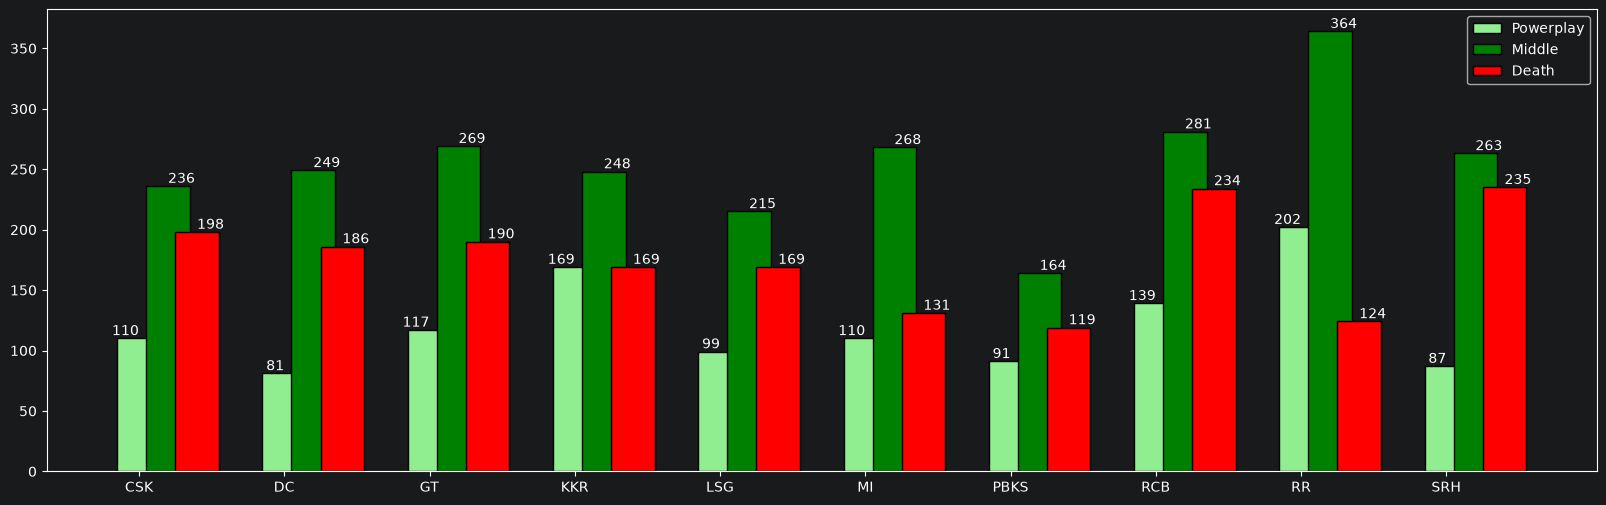

In [57]:
## here we drw the bar graph of this above phase wise team score
plt.figure(figsize=(20,6))

xval = np.arange(1,11)  #[1,2,3,4,5,6,7,8,9,10]

plt.bar(xval,edf['Powerplay(1-6)'],width=0.3,color='lightgreen',label='Powerplay',edgecolor='black')  #[1 2 3 4 5 6 7 8 9 10]
plt.bar(xval+0.2,edf['Middle(7-15)'],width=0.3,color='green',label='Middle',edgecolor='black') #[1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2,10.2]
plt.bar(xval+0.4,edf['Death(16-20)'],width=0.3,color='red',label='Death',edgecolor='black')
plt.legend()


for x,y in zip(xval,edf['Powerplay(1-6)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.2,edf['Middle(7-15)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='left')

for x,y in zip(xval+0.4,edf['Death(16-20)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='left')


plt.xticks(xval,edf['batting_team'])

plt.show()

## Batsman Analysis

## Top 10 Scorers In IPL 2026

In [22]:
edf = df.groupby('striker').agg(
    total = ('total_runs','sum')
).reset_index()

edf = edf.sort_values('total',ascending=False).head(10)
edf

,striker,total
101,Vaibhav Sooryavanshi,204
108,Yashasvi Jaiswal,193
22,Dhruv Jurel,185
80,Sameer Rizvi,175
4,Angkrish Raghuvanshi,163
29,Heinrich Klaasen,150
66,Rajat Patidar,149
105,Virat Kohli,142
21,Devdutt Padikkal,136
3,Ajinkya Rahane,131


In [68]:

plt.figure(figsize=(20,6))
plt.bar(edf['striker'],edf['total'],color='orange',edgecolor='black')
plt.title('Top Strikers')
plt.xlabel('Players')
plt.ylabel('Total Score')

for x,y in zip(edf['striker'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

KeyError: 'striker'

<Figure size 2000x600 with 0 Axes>

## Top Batsmen (Boundaries)

In [60]:
b = 'is_four'
edf = df.groupby('striker').agg(
    total = (b,'sum')
).reset_index()
edf = edf.sort_values('total',ascending=False).head(10)
edf

,striker,total
108,Yashasvi Jaiswal,19
101,Vaibhav Sooryavanshi,18
4,Angkrish Raghuvanshi,17
22,Dhruv Jurel,17
82,Sarfaraz Khan,16
21,Devdutt Padikkal,15
105,Virat Kohli,14
24,Finn Allen,13
78,Sai Sudharsan,13
59,Pathum Nissanka,12


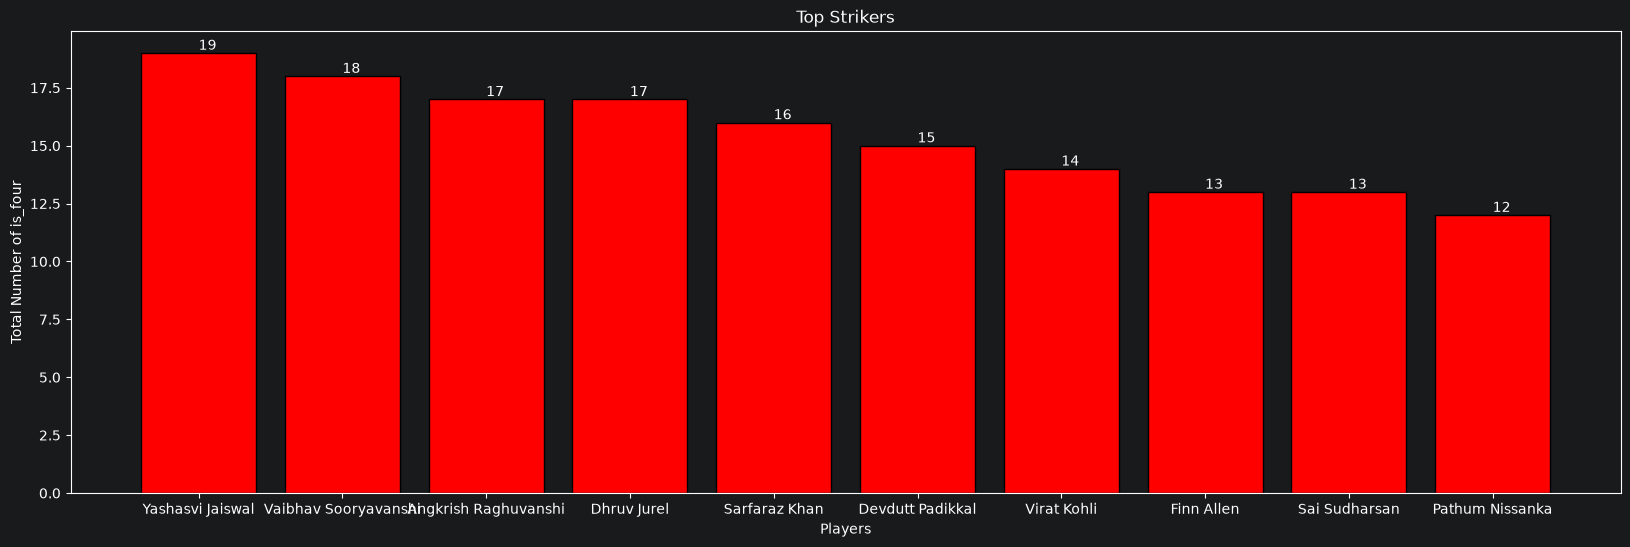

In [61]:
plt.figure(figsize=(20,6))
plt.bar(edf['striker'],edf['total'],color='red',edgecolor='black')
plt.title('Top Strikers')
plt.xlabel('Players')
plt.ylabel(f'Total Number of {b}')

for x,y in zip(edf['striker'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

## Strike Rate for Top Batsmen

1. formulae : (runs score / ball faced)  * 100
2. wide ball != balls faced

In [63]:
legal_balls = df.loc[ df['extras']==0 ]

edf = df.groupby('striker').agg(
    runs = ('runs_of_bat','sum'),
    balls = ('runs_of_bat','count')
).reset_index()

edf = edf.loc[ edf['balls']>=30 ]
edf['strike_rate'] = (edf['runs']/edf['balls'])*100
edf = edf.sort_values('strike_rate',ascending=False).head(10)
edf['strike_rate'] = edf['strike_rate'].round().astype(int)
edf


,striker,runs,balls,strike_rate
101,Vaibhav Sooryavanshi,200,78,256
96,Tim David,99,46,215
21,Devdutt Padikkal,125,63,198
24,Finn Allen,80,41,195
66,Rajat Patidar,141,74,191
82,Sarfaraz Khan,99,52,190
30,Ishan Kishan,96,52,185
22,Dhruv Jurel,176,102,173
105,Virat Kohli,129,76,170
77,Ryan Rickelton,98,59,166


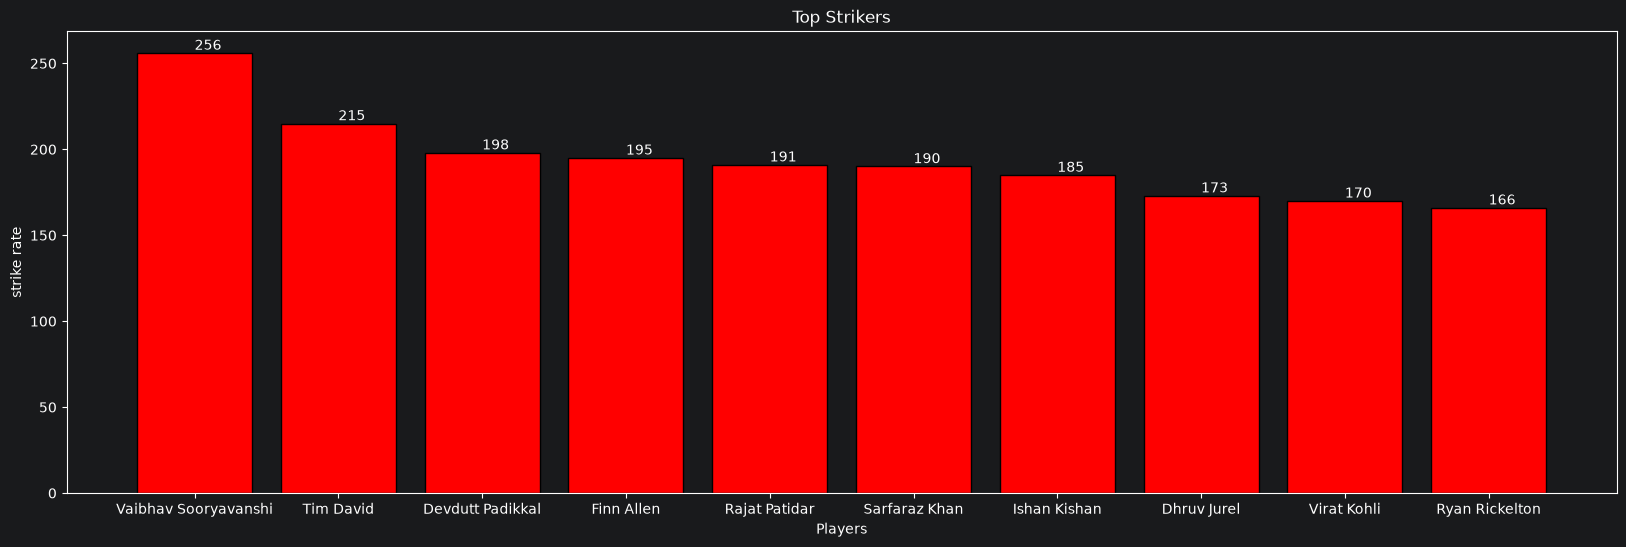

In [64]:
plt.figure(figsize=(20,6))
plt.bar(edf['striker'],edf['strike_rate'],color='red',edgecolor='black')
plt.title('Top Strikers')
plt.xlabel('Players')
plt.ylabel('strike rate')

for x,y in zip(edf['striker'],edf['strike_rate']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

## Bowler Analysis

## Most wickets in IPL 2026 - Bowlers

### run-outs are not credited to the bowler

In [28]:
df

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder,total_runs,is_six,is_four,is_wicket,phase_group
0,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,Powerplay(1-6)
1,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Powerplay(1-6)
2,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,Powerplay(1-6)
3,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN,6,1,0,0,Powerplay(1-6)
4,202601,2026,Group Stage,1,28-Mar-26,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,Powerplay(1-6)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3512,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,18.2,Ravindra Jadeja,Romario Shepherd,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Death(16-20)
3513,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,18.3,Dhruv Jurel,Romario Shepherd,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Death(16-20)
3514,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,18.4,Ravindra Jadeja,Romario Shepherd,1,0,0,0,0,0,NaN,NaN,NaN,1,0,0,0,Death(16-20)
3515,202616,2026,Group Stage,16,10-Apr-26,"Barsapara Cricket Stadium, Guwahati",RR,RCB,2,18.5,Dhruv Jurel,Romario Shepherd,6,0,0,0,0,0,NaN,NaN,NaN,6,1,0,0,Death(16-20)


In [65]:
bowler_wickets = df.loc[  (df['wicket_type'].notnull()) & (df['wicket_type']!='runout') ]


edf = bowler_wickets.groupby('bowler').agg(
    total = ('is_wicket','sum')
).reset_index()

edf = edf.sort_values('total',ascending=False).head(10)
edf

,bowler,total
43,Ravi Bishnoi,9
19,Jacob Duffy,6
40,Prasidh Krishna,6
2,Anshul Kamboj,5
54,Vaibhav Arora,5
42,Rashid Khan,5
41,Prince Yadav,5
37,Nandre Burger,5
36,Mukesh Kumar,5
28,Lungi Ngidi,5


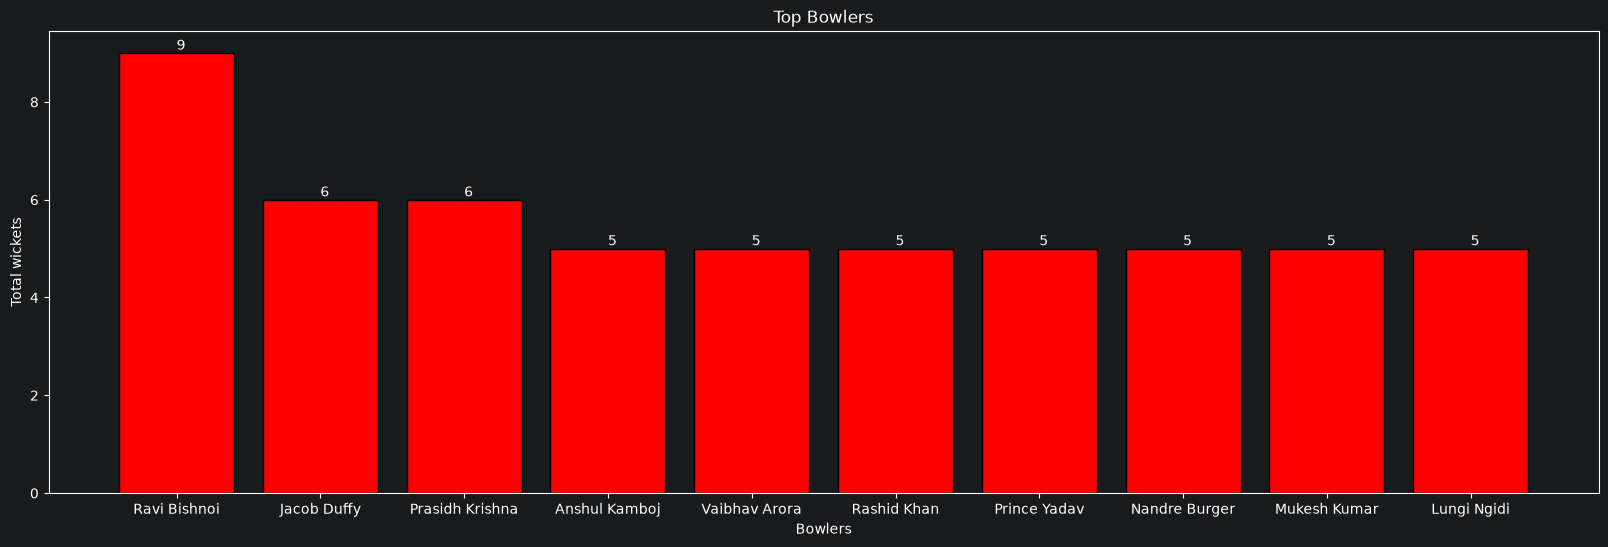

In [66]:
plt.figure(figsize=(20,6))
plt.bar(edf['bowler'],edf['total'],color='red',edgecolor='black')
plt.title('Top Bowlers')
plt.xlabel('Bowlers')
plt.ylabel('Total wickets')

for x,y in zip(edf['bowler'],edf['total']):
    plt.text(x=x,y=y,s=y,va='bottom')


plt.show()

## Which Bowler has best economy rate

## runs given per over

In [67]:
legal_balls = df.loc[ (df['wide']==0) & (df['noballs']==0) ]

edf = df.groupby('bowler').agg(
    total = ('runs_of_bat','sum'),
    balls = ('runs_of_bat','count')
).reset_index()

edf = edf.loc[ edf['balls']>=18 ]
edf['economy_rate'] = (edf['total']/edf['balls'])*6
edf = edf.sort_values('economy_rate').head(10)
edf

,bowler,total,balls,economy_rate
45,Mohsin Khan,18,25,4.320000
43,Mohammed Shami,58,77,4.519481
76,Yuzvendra Chahal,44,46,5.739130
55,Rashid Khan,79,74,6.405405
11,Axar Patel,69,62,6.677419
7,Anukul Roy,56,50,6.720000
35,Lungi Ngidi,82,73,6.739726
37,Marco Jansen,57,50,6.840000
66,Suyash Sharma,49,42,7.000000
14,Brijesh Sharma,52,44,7.090909


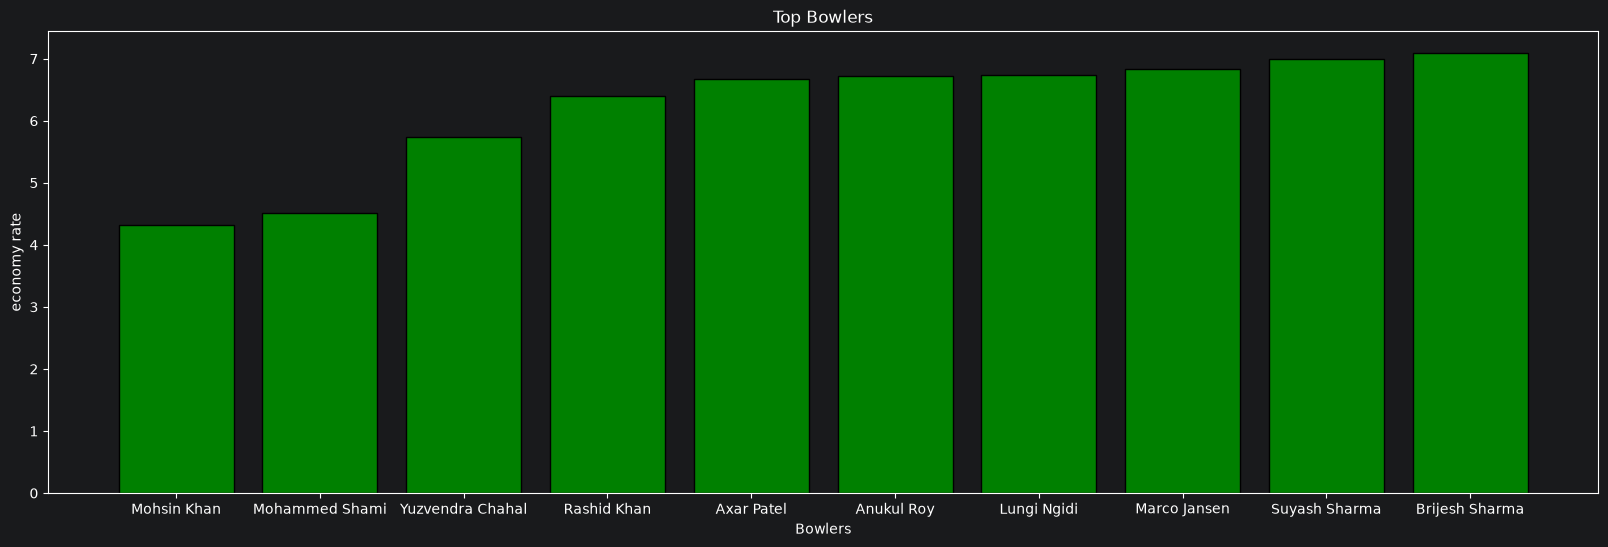

In [32]:
plt.figure(figsize=(20,6))
plt.bar(edf['bowler'],edf['economy_rate'],color='green',edgecolor='black')
plt.title('Top Bowlers')
plt.xlabel('Bowlers')
plt.ylabel('economy rate')
plt.show()

## How are batsmen getting out (wicket type breakdown)

In [33]:
edf = df['wicket_type'].value_counts().reset_index()
edf

,wicket_type,count
0,caught,141
1,bowled,29
2,runout,13
3,lbw,7
4,stumped,2


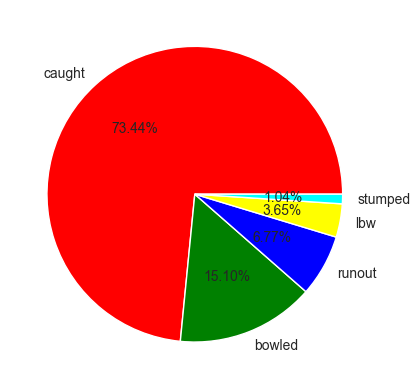

In [31]:
plt.pie( edf['count'],labels = edf['wicket_type'] , autopct='%0.2f%%', colors=['red','green','blue','yellow','cyan'] )

plt.show()

## Over by over analysis

## Average Run Rate over by over

In [34]:
df['over_number'] = df['over'].astype(int)

edf = df.groupby('over_number').agg(
    avg_runs = ('total_runs','mean'),

).reset_index()

edf['avg_runs'] = edf['avg_runs'].round(2)
edf

,over_number,avg_runs
0,1,1.48
1,2,1.46
2,3,1.57
3,4,1.65
4,5,1.78
5,6,1.68
6,7,1.48
7,8,1.49
8,9,1.62
9,10,1.25


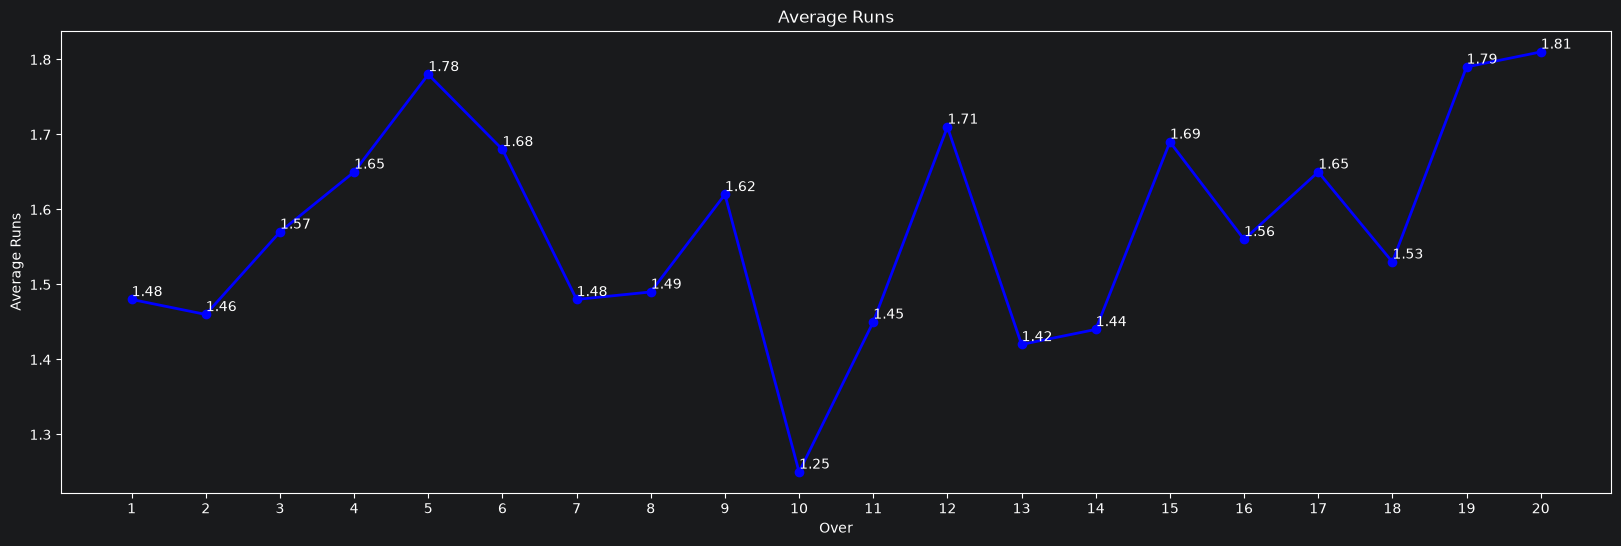

In [35]:
plt.figure(figsize=(20,6))
plt.plot(edf['over_number'],edf['avg_runs'],color='blue',marker='o',linewidth=2)
plt.title('Average Runs')
plt.xlabel('Over')
plt.ylabel('Average Runs')

plt.xticks( np.arange(1,21) )

for x,y in zip(edf['over_number'],edf['avg_runs']):
    plt.text(x=x,y=y,s=y,va='bottom')

plt.show()

## Which team is better in Powerplay , middle or in death overs ?

In [36]:
edf = df.groupby(['batting_team','phase_group']).agg(
    total = ('total_runs','sum')
).reset_index()

edf

,batting_team,phase_group,total
0,CSK,Death(16-20),171
1,CSK,Middle(7-15),224
2,CSK,Powerplay(1-6),149
3,DC,Death(16-20),156
4,DC,Middle(7-15),252
5,DC,Powerplay(1-6),108
6,GT,Death(16-20),160
7,GT,Middle(7-15),261
8,GT,Powerplay(1-6),155
9,KKR,Death(16-20),148


In [37]:
edf = df.pivot_table(index='batting_team',columns='phase_group',values='total_runs',aggfunc='sum').reset_index()
edf

phase_group,batting_team,Death(16-20),Middle(7-15),Powerplay(1-6)
0,CSK,171,224,149
1,DC,156,252,108
2,GT,160,261,155
3,KKR,148,238,200
4,LSG,148,211,124
5,MI,111,256,142
6,PBKS,109,153,112
7,RCB,208,278,168
8,RR,101,324,265
9,SRH,201,264,120


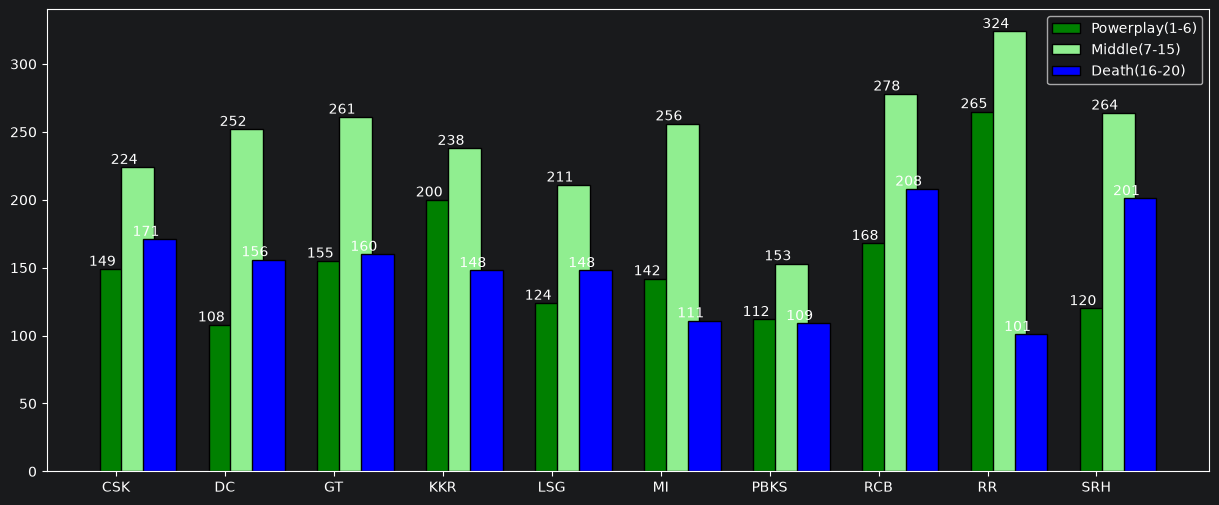

In [38]:
plt.figure(figsize=(15,6))

xval = np.arange(1,11)  #[1,2,3,4,5,6,7,8,9,10]

plt.bar(xval,edf['Powerplay(1-6)'],width=0.3,color='green',label='Powerplay(1-6)',edgecolor='black')  #[1 2 3 4 5 6 7 8 9 10]
plt.bar(xval+0.2,edf['Middle(7-15)'],width=0.3,color='lightgreen',label='Middle(7-15)',edgecolor='black') #[1.2,2.2,3.2,4.2,5.2,6.2,7.2,8.2,9.2,10.2]
plt.bar(xval+0.4,edf['Death(16-20)'],width=0.3,color='blue',label='Death(16-20)',edgecolor='black')
plt.legend()


for x,y in zip(xval,edf['Powerplay(1-6)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.2,edf['Middle(7-15)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')

for x,y in zip(xval+0.4,edf['Death(16-20)']):
    plt.text(x=x,y=y,s=y,va='bottom',ha='right')


plt.xticks(xval,edf['batting_team'])

plt.show()

# IPL 2026 Data Analysis — Detailed Summary

## 1. Dataset Overview

- **Source File:** `ipl_2026_deliveries.csv`
- **Shape:** 3,517 rows × 21 columns (ball-by-ball delivery data)
- **Season:** IPL 2026
- **Matches Covered:** 16 matches (Group Stage)
- **Teams:** 10 teams — SRH, RCB, KKR, MI, CSK, RR, GT, PBKS, LSG, DC

### Columns
`match_id`, `season`, `phase`, `match_no`, `date`, `venue`, `batting_team`, `bowling_team`, `innings`, `over`, `striker`, `bowler`, `runs_of_bat`, `extras`, `wide`, `legbyes`, `byes`, `noballs`, `wicket_type`, `player_dismissed`, `fielder`

### Missing Values
| Column | Nulls |
|---|---|
| wicket_type | 3,325 |
| player_dismissed | 3,329 |
| fielder | 3,365 |
> All other columns are complete with 0 nulls.

---

## 2. Feature Engineering

The following derived columns were created for analysis:

| New Column | Logic |
|---|---|
| `total_runs` | `runs_of_bat + extras` |
| `is_six` | 1 if `runs_of_bat == 6`, else 0 |
| `is_four` | 1 if `runs_of_bat == 4`, else 0 |
| `is_wicket` | 1 if `wicket_type` is not null, else 0 |
| `phase_group` | Powerplay (1–6), Middle (7–15), Death (16–20) |

---

## 3. Team-Wise Total Runs

| Rank | Team | Total Runs |
|---|---|---|
| 1 | RR | 690 |
| 2 | RCB | 654 |
| 3 | KKR | 586 |
| 4 | SRH | 585 |
| 5 | GT | 576 |
| 6 | CSK | 544 |
| 7 | DC | 516 |
| 8 | MI | 509 |
| 9 | LSG | 483 |
| 10 | PBKS | 374 |

> **RR** leads in total runs scored, followed by **RCB** and **KKR**. **PBKS** is the lowest-scoring team.

---

## 4. Team-Wise Boundaries (Fours & Sixes)

| Team | Sixes | Fours | Total Boundaries |
|---|---|---|---|
| RR | 42 | 59 | 101 |
| RCB | 39 | 51 | 90 |
| SRH | 29 | 50 | 79 |
| KKR | 24 | 57 | 81 |
| GT | 23 | 55 | 78 |
| CSK | 23 | 50 | 73 |
| MI | 23 | 50 | 73 |
| DC | 22 | 50 | 72 |
| LSG | 19 | 44 | 63 |
| PBKS | 23 | 29 | 52 |

> **RR** is the most aggressive team in boundary hitting with 101 total. **RCB** leads in sixes (39).
> **PBKS** hits the fewest fours (29) despite hitting 23 sixes.

---

## 5. Team Performance by Match Phase

| Team | Powerplay (1–6) | Middle (7–15) | Death (16–20) |
|---|---|---|---|
| CSK | 149 | 224 | 171 |
| DC | 108 | 252 | 156 |
| GT | 155 | 261 | 160 |
| KKR | 200 | 238 | 148 |
| LSG | 124 | 211 | 148 |
| MI | 142 | 256 | 111 |
| PBKS | 112 | 153 | 109 |
| RCB | 168 | 278 | 208 |
| RR | 265 | 324 | 101 |
| SRH | 120 | 264 | 201 |

**Key Observations:**
- **RR** dominates the **Powerplay** (265) and **Middle overs** (324) but is the weakest in Death overs (101).
- **RCB** is the best Death-over team (208) and also strong in Middle overs (278).
- **SRH** picks up significantly in Death overs (201).
- **KKR** is a strong Powerplay side (200).
- **PBKS** performs consistently but low across all phases.
- **Middle overs** are the highest-scoring phase for every team.

---

## 6. Top Run-Scorers (Batters)

| Rank | Player | Total Runs |
|---|---|---|
| 1 | Vaibhav Sooryavanshi | 204 |
| 2 | Yashasvi Jaiswal | 193 |
| 3 | Dhruv Jurel | 185 |
| 4 | Sameer Rizvi | 175 |
| 5 | Angkrish Raghuvanshi | 163 |
| 6 | Heinrich Klaasen | 150 |
| 7 | Rajat Patidar | 149 |
| 8 | Virat Kohli | 142 |
| 9 | Devdutt Padikkal | 136 |
| 10 | Ajinkya Rahane | 131 |

> **Vaibhav Sooryavanshi** tops the run charts in just 16 matches, showcasing explosive early-season form.

---

## 7. Top Four-Hitters (Batters)

| Rank | Player | Fours |
|---|---|---|
| 1 | Yashasvi Jaiswal | 19 |
| 2 | Vaibhav Sooryavanshi | 18 |
| 3 | Angkrish Raghuvanshi | 17 |
| 4 | Dhruv Jurel | 17 |
| 5 | Sarfaraz Khan | 16 |
| 6 | Devdutt Padikkal | 15 |
| 7 | Virat Kohli | 14 |
| 8 | Finn Allen | 13 |
| 9 | Sai Sudharsan | 13 |
| 10 | Pathum Nissanka | 12 |

---

## 8. Top Strike Rates (Batters with ≥30 balls)

| Rank | Player | Runs | Balls | Strike Rate |
|---|---|---|---|---|
| 1 | Vaibhav Sooryavanshi | 200 | 78 | 256 |
| 2 | Tim David | 99 | 46 | 215 |
| 3 | Devdutt Padikkal | 125 | 63 | 198 |
| 4 | Finn Allen | 80 | 41 | 195 |
| 5 | Rajat Patidar | 141 | 74 | 191 |
| 6 | Sarfaraz Khan | 99 | 52 | 190 |
| 7 | Ishan Kishan | 96 | 52 | 185 |
| 8 | Dhruv Jurel | 176 | 102 | 173 |
| 9 | Virat Kohli | 129 | 76 | 170 |
| 10 | Ryan Rickelton | 98 | 59 | 166 |

> **Vaibhav Sooryavanshi** has a phenomenal strike rate of **256**, the highest among qualified batters.
> **Tim David** (215) and **Devdutt Padikkal** (198) are also explosive finishers/top-order hitters.

---

## 9. Top Wicket-Takers (Bowlers)

*(Run-outs excluded)*

| Rank | Bowler | Wickets |
|---|---|---|
| 1 | Ravi Bishnoi | 9 |
| 2 | Jacob Duffy | 6 |
| 3 | Prasidh Krishna | 6 |
| 4 | Anshul Kamboj | 5 |
| 5 | Vaibhav Arora | 5 |
| 6 | Rashid Khan | 5 |
| 7 | Prince Yadav | 5 |
| 8 | Nandre Burger | 5 |
| 9 | Mukesh Kumar | 5 |
| 10 | Lungi Ngidi | 5 |

> **Ravi Bishnoi** is the standout wicket-taker with 9 wickets, well clear of the rest.

---

## 10. Best Economy Rates (Bowlers with ≥18 balls)

| Rank | Bowler | Runs | Balls | Economy |
|---|---|---|---|---|
| 1 | Mohsin Khan | 18 | 25 | 4.32 |
| 2 | Mohammed Shami | 58 | 77 | 4.52 |
| 3 | Yuzvendra Chahal | 44 | 46 | 5.74 |
| 4 | Rashid Khan | 79 | 74 | 6.41 |
| 5 | Axar Patel | 69 | 62 | 6.68 |
| 6 | Anukul Roy | 56 | 50 | 6.72 |
| 7 | Lungi Ngidi | 82 | 73 | 6.74 |
| 8 | Marco Jansen | 57 | 50 | 6.84 |
| 9 | Suyash Sharma | 49 | 42 | 7.00 |
| 10 | Brijesh Sharma | 52 | 44 | 7.09 |

> **Mohsin Khan** (4.32) and **Mohammed Shami** (4.52) are the most economical bowlers — exceptional for T20 cricket.
> Spinners **Yuzvendra Chahal** and **Rashid Khan** are also highly economical.

---

## 11. Wicket Types Distribution

| Wicket Type | Count | % |
|---|---|---|
| Caught | 141 | ~73.4% |
| Bowled | 29 | ~15.1% |
| Run Out | 13 | ~6.8% |
| LBW | 7 | ~3.6% |
| Stumped | 2 | ~1.0% |

> **Caught dismissals** dominate heavily (73%), which is typical of T20 cricket where big shots lead to edge catches.

---

## 12. Average Runs Per Ball by Over

| Over | Avg Runs |
|---|---|
| 1 | 1.48 |
| 2 | 1.46 |
| 3 | 1.57 |
| 4 | 1.65 |
| 5 | 1.78 |
| 6 | 1.68 |
| 7 | 1.48 |
| 8 | 1.49 |
| 9 | 1.62 |
| 10 | 1.25 |
| 11 | 1.45 |
| 12 | 1.71 |
| 13 | 1.42 |
| 14 | 1.44 |
| 15 | 1.69 |
| 16 | 1.56 |
| 17 | 1.65 |
| 18 | 1.53 |
| 19 | 1.79 |
| 20 | 1.81 |

**Key Observations:**
- Overs **19 and 20** are the highest scoring per ball (~1.79–1.81), as expected in T20 death overs.
- **Over 10** is the slowest (1.25), a common consolidation point in middle overs.
- **Over 5** (1.78) is a powerplay spike — batters accelerate before the field spreads.

---

## 13. Key Takeaways

1. **RR** is the strongest batting team overall — best in Powerplay and Middle overs.
2. **RCB** is the best Death-over team and the most aggressive six-hitting side.
3. **PBKS** is the weakest team across all metrics — runs, fours, and phase-wise performance.
4. **Vaibhav Sooryavanshi** is the standout batter — top runs AND highest strike rate (256).
5. **Ravi Bishnoi** leads the bowling charts comfortably with 9 wickets.
6. **Mohsin Khan** and **Mohammed Shami** are the most economical bowlers.
7. **Caught** dismissals account for nearly 3 in 4 wickets in IPL 2026 so far.
8. Scoring peaks in the final two overs (19–20), and dips around over 10.